In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings



warnings.filterwarnings('ignore')
import os

In [3]:
root_dir=r"C:\Users\User\Downloads\60 days of python\day-34(Edulumos)"
data_dir=os.path.join(root_dir,"data")
dataset=os.path.join(data_dir,"Mall_Customers.csv")


# **Loading the dataset**

In [4]:
df=pd.read_csv(dataset)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# **Exploratory data analysis**

<Axes: xlabel='count', ylabel='Gender'>

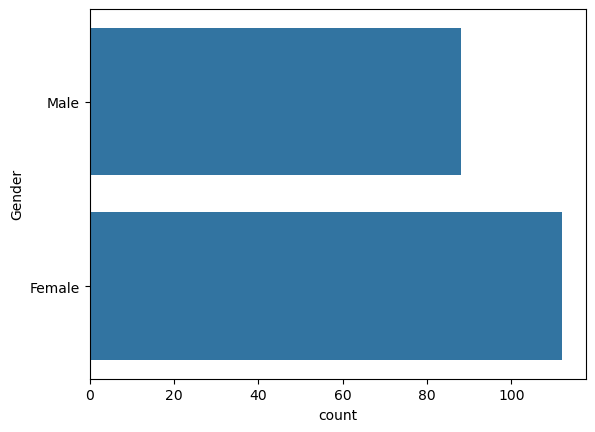

In [6]:
sns.countplot(df['Gender'],)

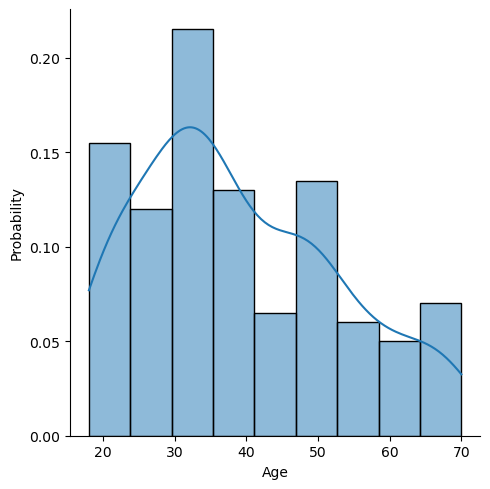

In [7]:
sns.displot(df['Age'],
            kind='hist',
            kde=True,
            stat='probability'
            )

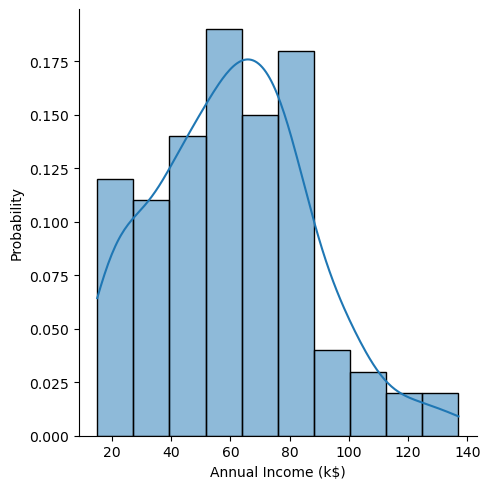

In [8]:
sns.displot(df['Annual Income (k$)'],kind='hist',
            kde=True,
            stat='probability'
            )

In [9]:
df=df.drop(columns=["Gender"])

<Axes: >

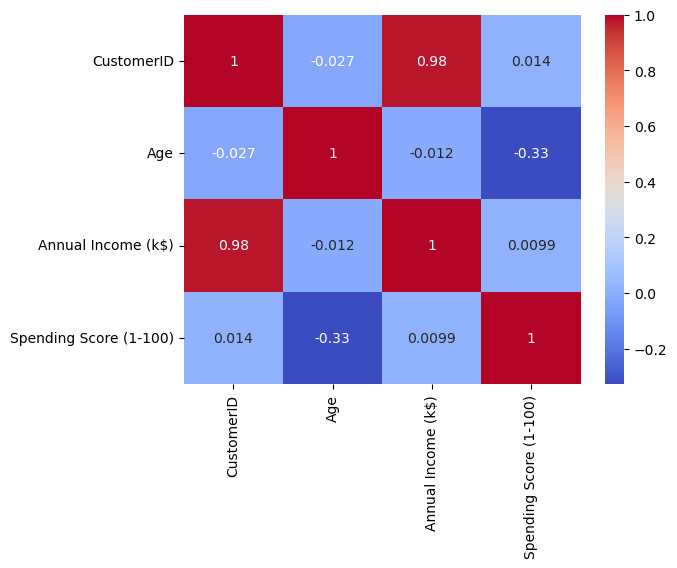

In [10]:
corr=df.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

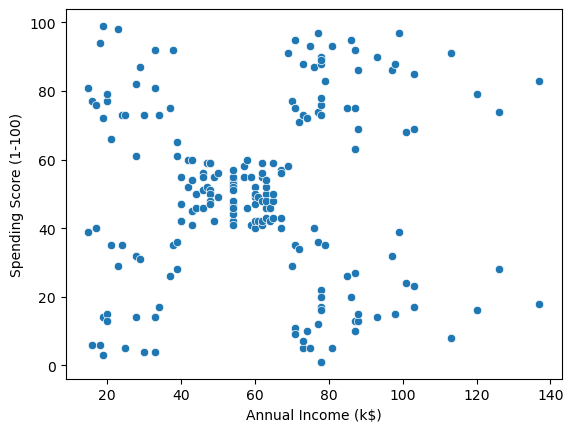

In [11]:
#cluster on 3 features
sns.scatterplot(x=df['Annual Income (k$)'],y=df['Spending Score (1-100)'])

In [12]:
from sklearn.cluster import KMeans
errors=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(df)
    errors.append(kmeans.inertia_)


([<matplotlib.axis.XTick at 0x25ce71eb740>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

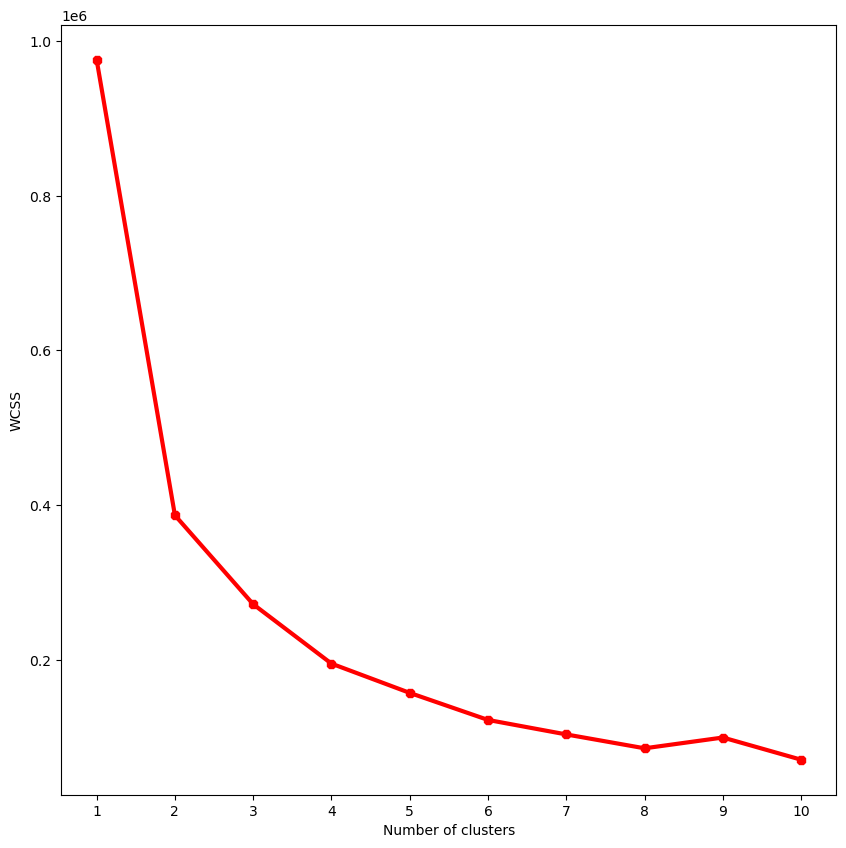

In [13]:
plt.figure(figsize=(10,10))
plt.plot(range(1,11),errors)
plt.plot(range(1,11),errors,linewidth=3,color='red',marker='8')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(np.arange(1,11,1))


In [14]:
df1=df[['Annual Income (k$)','Spending Score (1-100)']]


In [15]:
km=KMeans(n_clusters=5)
km.fit(df1)
y_pred=km.predict(df1)
df1['label']=y_pred
df1.head()



,Annual Income (k$),Spending Score (1-100),label
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

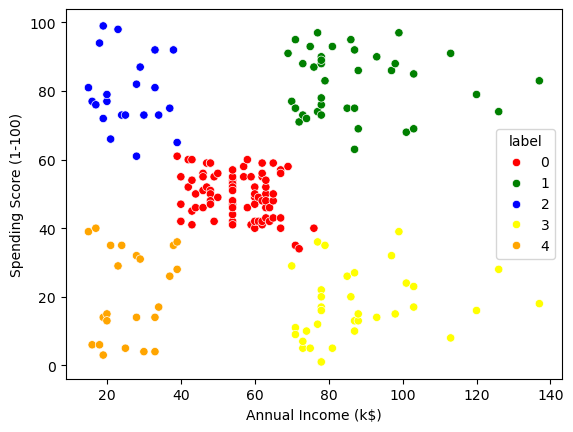

In [16]:
sns.scatterplot(df1,
                x=df1['Annual Income (k$)'],
                y=df1['Spending Score (1-100)'],
                hue=df1['label'],
                palette=['red','green','blue','yellow','orange']
                )

In [17]:
#clustering on 3 features
df2=df[['Annual Income (k$)','Spending Score (1-100)','Age']]
df2.head()

,Annual Income (k$),Spending Score (1-100),Age
0,15,39,19
1,15,81,21
2,16,6,20
3,16,77,23
4,17,40,31


In [18]:
errors=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(df2)
    errors.append(kmeans.inertia_)

([<matplotlib.axis.XTick at 0x25ce7982db0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

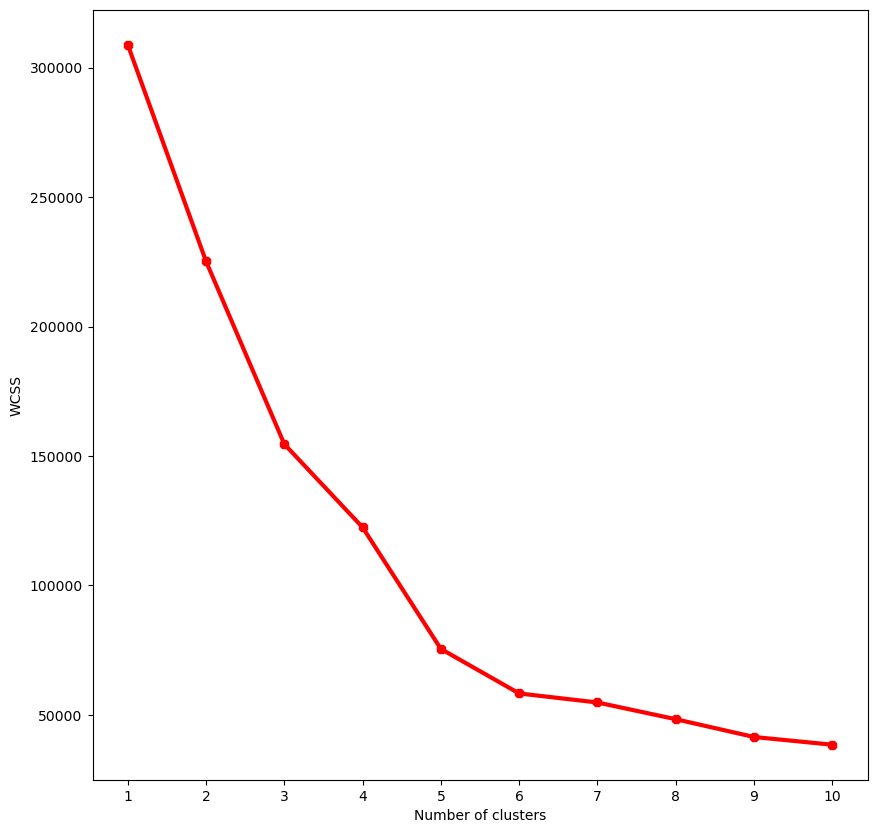

In [19]:
plt.figure(figsize=(10,10))
plt.plot(range(1,11),errors)
plt.plot(range(1,11),errors,linewidth=3,color='red',marker='8')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(np.arange(1,11,1))

In [20]:
km=KMeans(n_clusters=6)
km.fit(df2)
y_pred=km.predict(df2)
df2['label']=y_pred
df2



,Annual Income (k$),Spending Score (1-100),Age,label
0,15,39,19,3
1,15,81,21,2
2,16,6,20,3
3,16,77,23,2
4,17,40,31,3
...,...,...,...,...
195,120,79,35,0
196,126,28,45,4
197,126,74,32,0
198,137,18,32,4


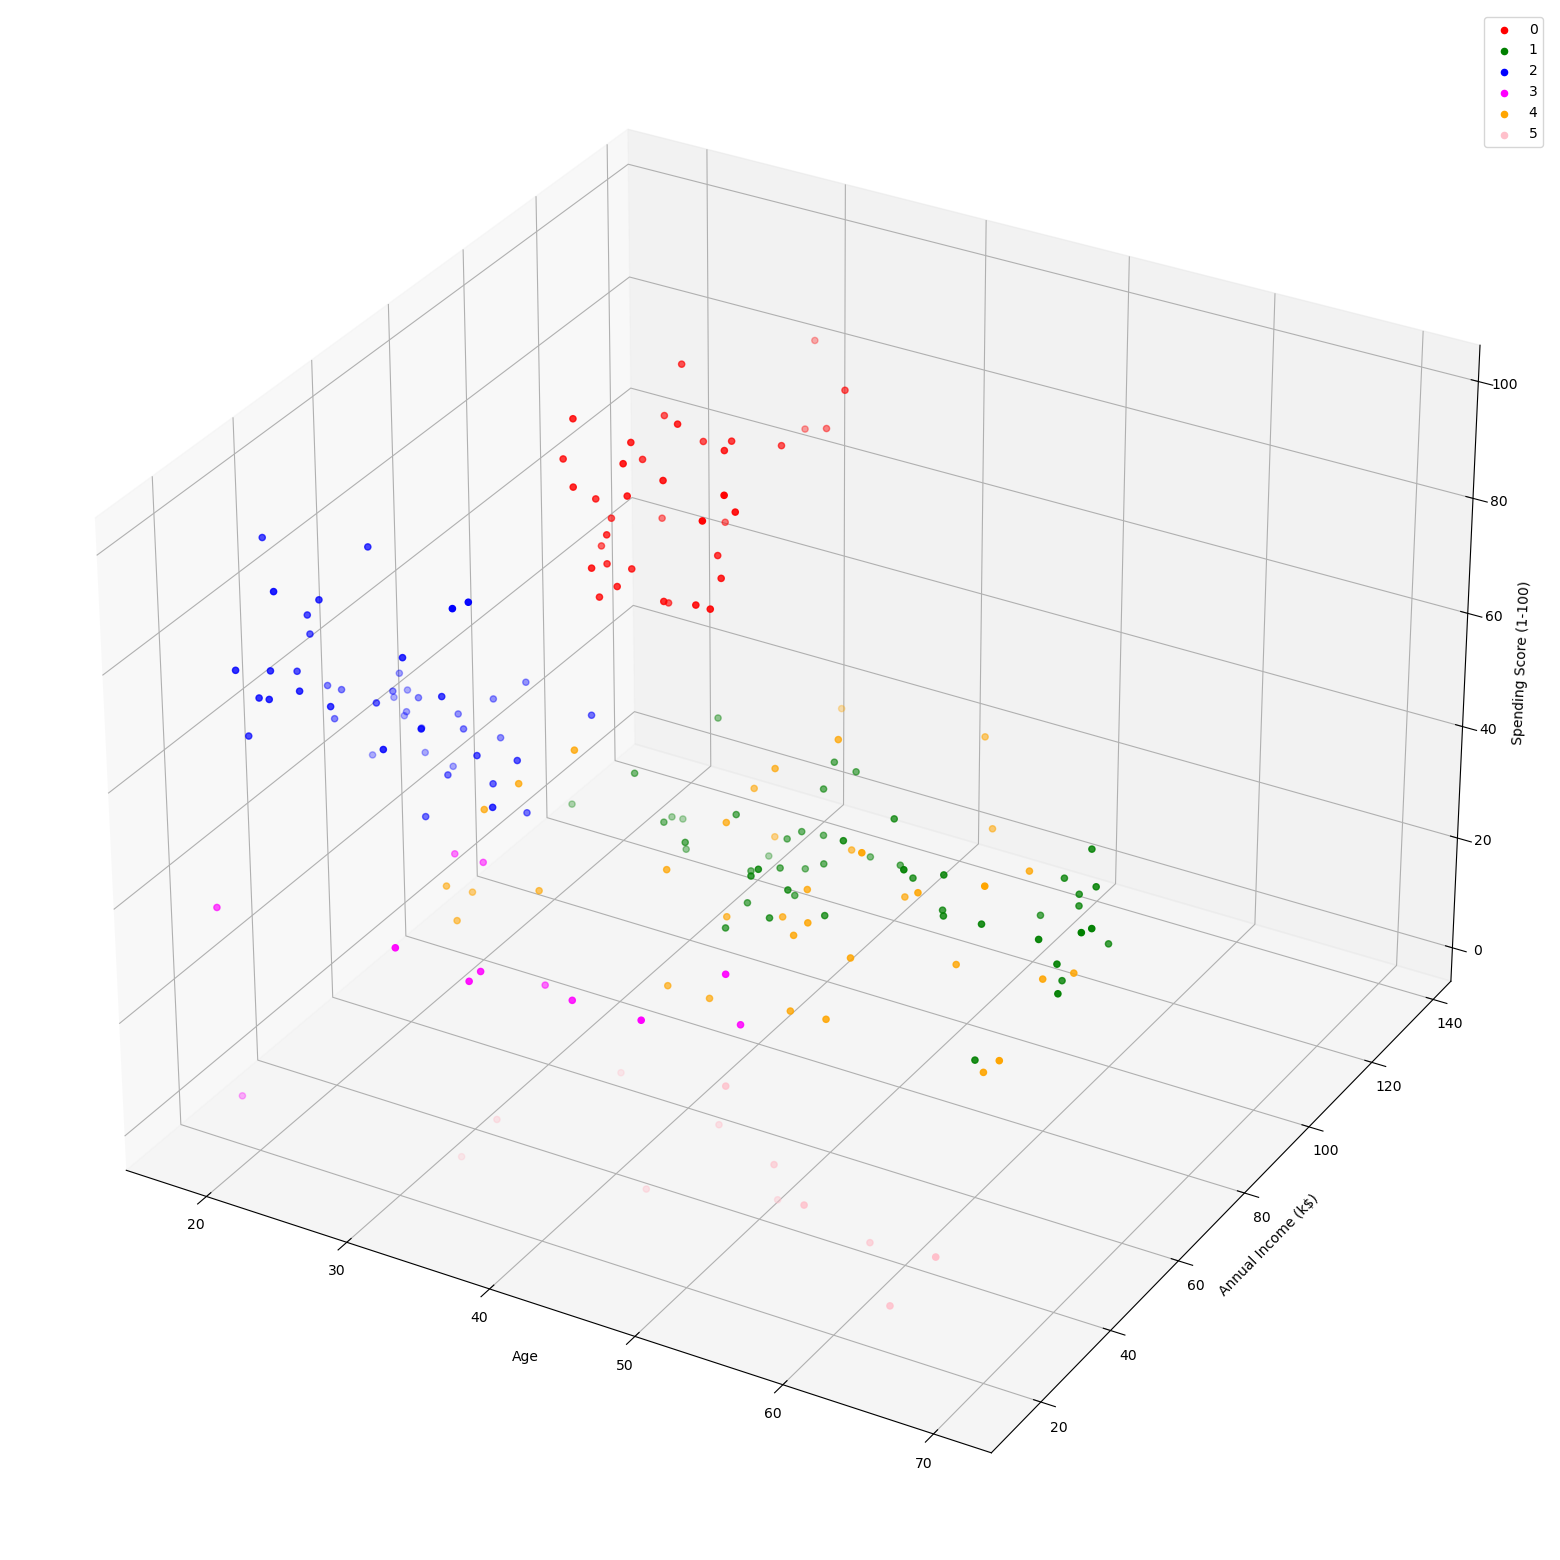

In [21]:
fig=plt.figure(figsize=(20,20))
ax=fig.add_subplot(1,1,1,projection='3d')

ax.scatter(df2['Age'][df2['label']==0],df2['Annual Income (k$)'][df2['label']==0],df2['Spending Score (1-100)'][df2['label']==0],c='red')
ax.scatter(df2['Age'][df2['label']==1],df2['Annual Income (k$)'][df2['label']==1],df2['Spending Score (1-100)'][df2['label']==1],c='green')
ax.scatter(df2['Age'][df2['label']==2],df2['Annual Income (k$)'][df2['label']==2],df2['Spending Score (1-100)'][df2['label']==2],c='blue')
ax.scatter(df2['Age'][df2['label']==3],df2['Annual Income (k$)'][df2['label']==3],df2['Spending Score (1-100)'][df2['label']==3],c='magenta')
ax.scatter(df2['Age'][df2['label']==4],df2['Annual Income (k$)'][df2['label']==4],df2['Spending Score (1-100)'][df2['label']==4],c='orange')
ax.scatter(df2['Age'][df2['label']==5],df2['Annual Income (k$)'][df2['label']==5],df2['Spending Score (1-100)'][df2['label']==5],c='pink')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.legend('012345')
#ax.view_init(45,190)
plt.show()


In [22]:
S

NameError: name 'S' is not defined